# ROC Curves — Delphi model comparison

For each model, runs inference on each patient using the checkpoint
of the fold in which that patient was in the validation set.
Plots ROC curves for selected diseases across all 3 models.

In [1]:
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from sklearn.metrics import roc_curve, auc as sklearn_auc

In [2]:
ROOT = Path().resolve()
for _ in range(6):
    if (ROOT / "delphi_labels_chapters_colours_icd.csv").exists():
        break
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from model import Delphi, DelphiConfig
from utils import get_p2i, get_batch

FIG_DIR  = ROOT / "figures"
DATA_DIR = ROOT / "data" / "ukb_simulated_data"
FIG_DIR.mkdir(exist_ok=True)

MODELS = {
    "Delphi":   ROOT / "out" / "delphi",
    "Model 1":  ROOT / "out" / "ours_m1",
    "Model 2":  ROOT / "out" / "ours_m2",
}
N_FOLDS = 10
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_COLORS = ["#1f77b4", "#2ca02c", "#9467bd"]


DISEASE_TOKENS =  [] #  leave empty for auto-selection

N_AUTO_DISEASES = 2   # how many to auto-select if DISEASE_TOKENS is empty

plt.rcParams.update({
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.dpi": 150,
})

In [3]:
# load data
train_data = np.memmap(DATA_DIR / "train.bin", dtype=np.uint32, mode="r").reshape(-1, 3)
val_data   = np.memmap(DATA_DIR / "val.bin",   dtype=np.uint32, mode="r").reshape(-1, 3)
all_data   = np.concatenate([train_data, val_data], axis=0)
all_p2i    = get_p2i(all_data)

print(f"Total patients: {len(all_p2i):,}")
print(f"Total events:   {len(all_data):,}")

Total patients: 14,286
Total events:   362,586


In [4]:
labels = pd.read_csv(ROOT / "delphi_labels_chapters_colours_icd.csv")
EXCLUDED = {"Technical", "Sex", "Smoking, Alcohol and BMI"}
disease_labels = labels[~labels["ICD-10 Chapter (short)"].isin(EXCLUDED)].copy()

if not DISEASE_TOKENS:
    token_counts = pd.Series(all_data[:, 2]).value_counts()
    DISEASE_TOKENS = (
        disease_labels
        .set_index("index")["name"]
        .reindex(token_counts.index)
        .dropna()
        .index[:N_AUTO_DISEASES]
        .tolist()
    )
    print(f"Auto-selected diseases: "
          f"{[disease_labels.set_index('index').loc[t, 'name'] for t in DISEASE_TOKENS]}")

disease_names = {
    t: disease_labels.set_index("index").loc[t, "name"]
    if t in disease_labels["index"].values else f"Token {t}"
    for t in DISEASE_TOKENS
}

Auto-selected diseases: ['I09 Other rheumatic heart diseases', 'M77 Other enthesopathies']


In [5]:

def load_model_from_ckpt(ckpt_path: Path, device: str) -> Delphi:
    ckpt  = torch.load(ckpt_path, map_location=device, weights_only=False)
    model_args = dict(ckpt["model_args"])
    state = {k.replace("_orig_mod.", ""): v for k, v in ckpt["model"].items()}

    enc_weights = sorted([k for k in state if k.startswith("mlp_enc") and state[k].ndim == 2])
    has_adapter  = len(enc_weights) > 0

    if has_adapter:
        pretrained_embd_dim = state[enc_weights[0]].shape[1]
        n_linear = len(enc_weights)   

        adapter_n_hidden = (state[enc_weights[0]].shape[0]
                            if n_linear > 1 else pretrained_embd_dim)

        model_args["pretrained_embd_dim"] = pretrained_embd_dim
        model_args["adapter_n_layers"]    = n_linear
        model_args["adapter_n_hidden"]    = adapter_n_hidden
        dummy_emb = np.zeros((model_args["vocab_size"], pretrained_embd_dim), dtype=np.float32)
        model_args["pretrained_embeddings"] = "loaded_from_checkpoint"
    else:
        dummy_emb = None
        model_args["pretrained_embeddings"] = None

    conf  = DelphiConfig(**model_args)
    model = Delphi(conf, pretrained_embeddings=dummy_emb)
    model.load_state_dict(state)
    model.eval()
    return model.to(device)


def get_patient_score(model, patient_idx, all_data, all_p2i, disease_token, device,
                      block_size=48, no_event_token_rate=5):
    """
    Returns the logit for disease_token at the last valid position
    of this patient's sequence.
    """
    ix = torch.tensor([patient_idx])
    with torch.no_grad():
        x, a, y, b = get_batch(
            ix, all_data, all_p2i,
            block_size=block_size,
            device=device,
            select="left",
            padding="random",
            no_event_token_rate=no_event_token_rate,
            cut_batch=False,
        )
        logits, _, _ = model(x, a)   # (1, T, V)

    # find last non-padding position
    tokens = x[0].cpu().numpy()
    last_pos = int(np.max(np.where(tokens > 0)[0])) if (tokens > 0).any() else 0
    score = logits[0, last_pos, disease_token].item()
    return score


def patient_has_disease(patient_idx, all_data, all_p2i, disease_token):
    """True if the patient's trajectory contains disease_token at any point."""
    start, length = all_p2i[patient_idx]
    patient_tokens = all_data[start:start + length, 2]
    return int(disease_token) in patient_tokens.tolist()

In [6]:
# check that a patient has the disease and its on the val set 
all_scores = {}  

for model_label, model_dir in MODELS.items():
    model_dir = Path(model_dir)
    if not model_dir.exists():
        print(f"Skipping {model_label} — directory not found: {model_dir}")
        continue

    print(f"\n{'='*50}")
    print(f"Model: {model_label}")
    all_scores[model_label] = {t: {"scores": [], "labels": []} for t in DISEASE_TOKENS}

    loaded_model = None
    loaded_fold  = None

    for fold in range(1, N_FOLDS + 1):
        fold_dir    = model_dir / f"fold_{fold}"
        ckpt_path   = fold_dir / "ckpt.pt"
        val_ids_path = fold_dir / "val_ids.npy"

        if not ckpt_path.exists() or not val_ids_path.exists():
            print(f"  Fold {fold}: missing files, skipping")
            continue

        val_ids = np.load(val_ids_path)
        print(f"  Fold {fold}: {len(val_ids)} val patients", end="", flush=True)

        # load model only once per fold
        if loaded_fold != fold:
            loaded_model = load_model_from_ckpt(ckpt_path, DEVICE)
            loaded_fold  = fold

        for patient_idx in val_ids:
            label_cache = {}   
            for disease_token in DISEASE_TOKENS:
                score = get_patient_score(
                    loaded_model, patient_idx,
                    all_data, all_p2i,
                    disease_token, DEVICE,
                )
                if patient_idx not in label_cache:
                    label_cache[patient_idx] = {}
                label_cache[patient_idx][disease_token] = (
                    1 if patient_has_disease(patient_idx, all_data, all_p2i, disease_token)
                    else 0
                )
                all_scores[model_label][disease_token]["scores"].append(score)
                all_scores[model_label][disease_token]["labels"].append(
                    label_cache[patient_idx][disease_token]
                )

        # free GPU memory between folds
        del loaded_model
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
        loaded_model = None
        loaded_fold  = None
        print("  done")



Model: Delphi
  Fold 1: 1429 val patientsnumber of parameters: 2.24M
  done
  Fold 2: 1429 val patientsnumber of parameters: 2.24M
  done
  Fold 3: 1429 val patientsnumber of parameters: 2.24M
  done
  Fold 4: 1429 val patientsnumber of parameters: 2.24M
  done
  Fold 5: 1429 val patientsnumber of parameters: 2.24M
  done
  Fold 6: 1429 val patientsnumber of parameters: 2.24M
  done
  Fold 7: 1428 val patientsnumber of parameters: 2.24M
  done
  Fold 8: 1428 val patientsnumber of parameters: 2.24M
  done
  Fold 9: 1428 val patientsnumber of parameters: 2.24M
  done
  Fold 10: 1428 val patientsnumber of parameters: 2.24M
  done

Model: Model 1
  Fold 1: 1429 val patientsnumber of parameters: 8.28M
  done
  Fold 2: 1429 val patientsnumber of parameters: 8.28M
  done
  Fold 3: 1429 val patientsnumber of parameters: 8.28M
  done
  Fold 4: 1429 val patientsnumber of parameters: 8.28M
  done
  Fold 5: 1429 val patientsnumber of parameters: 8.28M
  done
  Fold 6: 1429 val patientsnumber of p

## ROC Curves

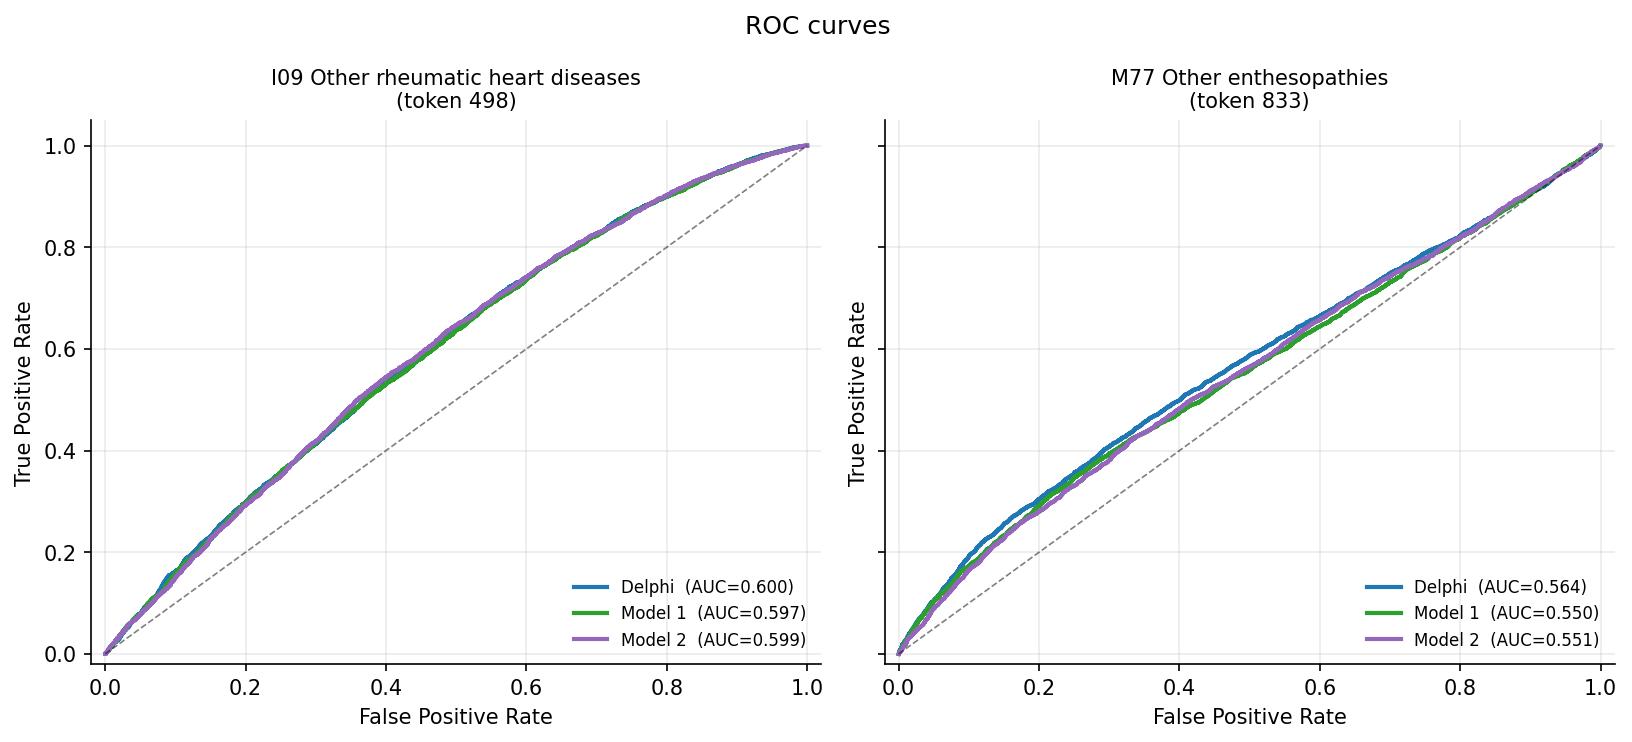

In [7]:
n_diseases = len(DISEASE_TOKENS)
fig, axes  = plt.subplots(1, n_diseases,
                           figsize=(5.5 * n_diseases, 5),
                           sharey=True)
if n_diseases == 1:
    axes = [axes]

for ax, disease_token in zip(axes, DISEASE_TOKENS):
    dis_name = disease_names[disease_token]

    for (model_label, _), color in zip(MODELS.items(), MODEL_COLORS):
        if model_label not in all_scores:
            continue

        scores = np.array(all_scores[model_label][disease_token]["scores"])
        labels = np.array(all_scores[model_label][disease_token]["labels"])

        n_pos = labels.sum()
        n_neg = (1 - labels).sum()

        if n_pos == 0 or n_neg == 0:
            print(f"  {model_label} / {dis_name}: skipping (no positives or no negatives)")
            continue

        fpr, tpr, _ = roc_curve(labels, scores)
        roc_auc     = sklearn_auc(fpr, tpr)

        ax.plot(fpr, tpr, color=color, lw=2.0,
                label=f"{model_label}  (AUC={roc_auc:.3f})")
        # ax.fill_between(fpr, tpr, alpha=0.06, color=color)  ← ELIMINADO

    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{dis_name}\n(token {disease_token})", fontsize=10)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)

    if all_scores:
        last = list(all_scores.values())[-1][disease_token]["labels"]
        n_pos_total = int(sum(last))
        n_total     = len(last)
       

fig.suptitle("ROC curves",
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "figE_roc_curves.png", bbox_inches="tight")
plt.show()